### Les librairies et importer les données :

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

In [ ]:
"""
mainpath = "xxx"
df = pd.read_csv(mainpath + "used_cars_data.csv")

df = df[df["bed"].isna()]
df = df[df["cabin"].isna()]
df = df[df["frame_damaged"] != True]
df = df[df["has_accidents"] != True]
df = df[df["isCab"] != True]
df = df[~df["main_picture_url"].isna()]
df = df[(df["owner_count"].isna()) | (df["owner_count"] == 1)]
df = df[df["salvage"] != True]
df = df[df["theft_title"] != True]
df = df[df["daysonmarket"] < 365]
df = df.drop(["bed", "bed_height", "cabin", "city", "dealer_zip",
              "description", "exterior_color", "has_accidents", "interior_color",
              "isCab", "frame_damaged", "latitude", "longitude", "main_picture_url", "owner_count",
              "is_certified", "is_cpo", "salvage", "savings_amount", "seller_rating", "sp_id", "theft_title",
              "vehicle_damage_category"], axis=1)

df_cars_short, df_reste = train_test_split(df, test_size=0.5, random_state=42)
df_cars_short.to_csv(mainpath + "used_cars_data_shorter.csv", index=False)
"""

### 1. Fonction Wrangle (EDA) :

(voir l'autre notebook pour connaître les explications et les graphiques derrière chaque décision)

In [2]:
def wrangle (df):
    df = df.drop_duplicates()

    df['back_legroom (in)'] = (
        df['back_legroom']
        .str.replace(" in", "", regex=False)
        .replace("--", np.nan , regex=False)
        .astype(float)
    )
    df['back_legroom (in)'] = df['back_legroom (in)'].fillna(38.14) #mean

    df['body_type'] = df['body_type'].fillna('SUV / Crossover')
    categories = df["body_type"].value_counts().nlargest(3).index
    df["body_type"] = df["body_type"].where(
        df["body_type"].isin(categories),
        "Autres"
    )

    df['city_fuel_economy'] = df['city_fuel_economy'].fillna(22) #median

    df['engine_cylinders'] = df['engine_cylinders'].fillna("I4")
    categories = df["engine_cylinders"].value_counts().nlargest(8).index
    df["engine_cylinders"] = df["engine_cylinders"].where(
        df["engine_cylinders"].isin(categories),
        "Autres"
    )

    df['engine_displacement'] = df['engine_displacement'].fillna(2500) #median

    df['franchise_make'] = df['franchise_make'].fillna('Ford')
    categories = df['franchise_make'].value_counts().nlargest(25).index
    df['franchise_make'] = df['franchise_make'].where(
        df['franchise_make'].isin(categories),
        "Autres"
    )

    df['front_legroom (in)'] = (
        df['front_legroom']
        .str.replace(" in", "", regex=False)
        .replace("--", np.nan , regex=False)
        .astype(float)
    )
    df['front_legroom (in)'] = df['front_legroom (in)'].fillna(42.19) #mean

    df['fuel_tank_volume (gal)'] = (
        df['fuel_tank_volume']
        .str.replace(" gal", "", regex=False)
        .replace("--", np.nan , regex=False)
        .astype(float)
    )
    df['fuel_tank_volume (gal)'] = df['fuel_tank_volume (gal)'].fillna(18.26) #mean

    df['fuel_type'] = df['fuel_type'].fillna("Gasoline")
    categories = df['fuel_type'].value_counts().nlargest(3).index
    df['fuel_type'] = df['fuel_type'].where(
        df['fuel_type'].isin(categories),
        "Autres"
    )

    df['height (in)'] = (
        df['height']
        .str.replace(" in", "", regex=False)
        .replace("--", np.nan , regex=False)
        .astype(float)
    )
    df['height (in)'] = df['height (in)'].fillna(66) #mean

    df['highway_fuel_economy'] = df['highway_fuel_economy'].fillna(29) #median

    df['horsepower'] = df['horsepower'].fillna(240) #median

    df['length (in)'] = (
        df['length']
        .str.replace(" in", "", regex=False)
        .replace("--", np.nan, regex=False)
        .astype(float)
    )
    df['length (in)'] = df['length (in)'].fillna(193.07) #mean

    categories = df['listing_color'].value_counts().nlargest(7).index
    df['listing_color'] = df['listing_color'].where(
        df['listing_color'].isin(categories),
        "Autres"
    )

    df['maximum_seating'] = (
        df['maximum_seating']
        .str.replace(" seats", "", regex=False)
        .replace("--", np.nan, regex=False)
        .astype(float)
    )
    df['maximum_seating'] = df['maximum_seating'].fillna(5) #median

    df['mileage'] = df['mileage'].fillna(15075.83) #mean

    df['power (RPM)'] = (
        df['power']
        .str.split("@").str[1]
        .str.replace(" RPM", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("'", "", regex=False)
        .astype(float)
    )
    df['power (RPM)'] = df['power (RPM)'].fillna(5761.10) #mean

    df['torque (RPM)'] = (
        df['torque']
        .str.split("@").str[1]
        .str.replace(" RPM", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("'", "", regex=False)
        .astype(float)
    )
    df['torque (lb-ft)'] = (
        df['torque']
        .str.split("@").str[0]
        .str.replace(" lb-ft", "", regex=False)
        .astype(float)
    )
    df['torque (lb-ft)'] = df['torque (lb-ft)'].fillna(258) #median
    df['torque (RPM)'] = df['torque (RPM)'].fillna(4000) #median

    df['transmission'] = df['transmission'].fillna("A")

    df['wheel_system'] = df['wheel_system'].fillna("FWD")

    df['wheelbase (in)'] = (
        df['wheelbase']
        .str.replace(" in", "", regex=False)
        .replace("--", np.nan, regex=False)
        .astype(float)
    )
    df['wheelbase (in)'] = df['wheelbase (in)'].fillna(115.07) #mean


    df['width (in)'] = (
        df['width']
        .str.replace(" in", "", regex=False)
        .replace("--", np.nan, regex=False)
        .astype(float)
    )
    df['width (in)'] = df['width (in)'].fillna(78.64) #mean

    df = df.drop(['vin', 'back_legroom', 'bed_length', 'combine_fuel_economy', 'engine_type', 'fleet', 'front_legroom', 'fuel_tank_volume', 'height', 'is_oemcpo', 'length', 'listed_date', 'listing_id', 'major_options', 'make_name', 'model_name', 'power', 'sp_name', 'torque', 'transmission_display', 'trimId', 'trim_name', 'wheel_system_display', 'wheelbase', 'width'], axis =1)
    return df


In [3]:
mainpath = "xxx"
df = pd.read_csv(mainpath + "used_cars_data_shorter.csv")
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

df_train = wrangle(df_train)
df_test = wrangle(df_test)

### 2. Multicolinéarité :

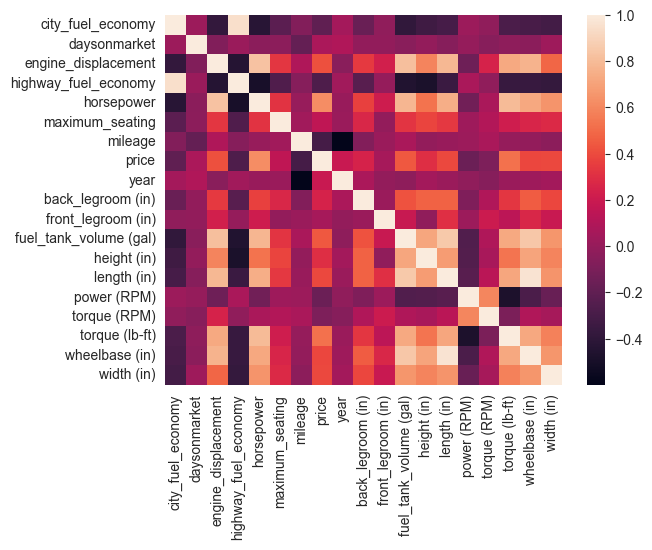

In [4]:
num_var = ['city_fuel_economy','daysonmarket','engine_displacement','highway_fuel_economy','horsepower','maximum_seating', 'mileage', 'price', 'year', 'back_legroom (in)', 'front_legroom (in)', 'fuel_tank_volume (gal)', 'height (in)', 'length (in)', 'power (RPM)', 'torque (RPM)', 'torque (lb-ft)', 'wheelbase (in)', 'width (in)']
sns.heatmap(df_train[num_var].corr());

Les variables que l'on supprime sont : 'city_fuel_economy', 'engine_displacement', 'fuel_tank_volume (gal)', 'length (in)', 'torque (lb-ft)', 'wheelbase (in)'

In [5]:
df_train = df_train.drop(['city_fuel_economy', 'engine_displacement', 'fuel_tank_volume (gal)', 'length (in)', 'torque (lb-ft)', 'wheelbase (in)'], axis=1)
df_test = df_test.drop(['city_fuel_economy', 'engine_displacement', 'fuel_tank_volume (gal)', 'length (in)', 'torque (lb-ft)', 'wheelbase (in)'], axis=1)

### 3. Stabilité (PSI) :

**Variables continues**

In [6]:
def psi(train, test, bins=10):
    breakpoints = np.linspace(np.min(train), np.max(train), bins + 1)
    train_counts = np.histogram(train, bins=breakpoints)[0] / len(train)
    test_counts = np.histogram(test, bins=breakpoints)[0] / len(test)
    train_counts = np.where(train_counts == 0, 0.001, train_counts)
    test_counts = np.where(test_counts == 0, 0.001, test_counts)
    psi_value = np.sum((test_counts - train_counts) * np.log(test_counts / train_counts))
    return psi_value


for col in ['daysonmarket','highway_fuel_economy','horsepower','maximum_seating', 'mileage', 'price', 'year', 'back_legroom (in)', 'front_legroom (in)', 'height (in)', 'power (RPM)', 'torque (RPM)','width (in)']:
    print(f"PSI {col}: {psi(df_train[col].dropna(), df_test[col].dropna()):.4f}")

PSI daysonmarket: 0.0001
PSI highway_fuel_economy: 0.0000
PSI horsepower: 0.0056
PSI maximum_seating: 0.0001
PSI mileage: 0.0183
PSI price: 0.0286
PSI year: 0.0000
PSI back_legroom (in): 0.0121
PSI front_legroom (in): 0.0001
PSI height (in): 0.0001
PSI power (RPM): 0.0000
PSI torque (RPM): 0.0000
PSI width (in): 0.0001


**Variables qualitatives**

In [7]:
def psi_cat(train, test):
    cats = set(train.unique()) | set(test.unique())
    train_dist = train.value_counts(normalize=True)
    test_dist = test.value_counts(normalize=True)
    psi_value = 0
    for cat in cats:
        p = train_dist.get(cat, 0.001)
        q = test_dist.get(cat, 0.001)
        if p == 0: p = 0.001
        if q == 0: q = 0.001
        psi_value += (q - p) * np.log(q / p)
    return psi_value


for col in ["body_type", "engine_cylinders", "franchise_make", "fuel_type", "listing_color", "transmission", "wheel_system"]:
    print(f"PSI {col}: {psi_cat(df_train[col], df_test[col]):.4f}")

PSI body_type: 0.0000
PSI engine_cylinders: 0.0001
PSI franchise_make: 0.0001
PSI fuel_type: 0.0000
PSI listing_color: 0.0001
PSI transmission: 0.0000
PSI wheel_system: 0.0000


Toutes les variables sont stables.

### 4. Valeurs extrêmes :

(voir l'autre notebook pour connaître les explications et les graphiques derrière chaque décision)

**On met la fonction Wrangle à jour :**

In [8]:
def wrangle (df):
    df = df.drop_duplicates()

    df['back_legroom (in)'] = (
        df['back_legroom']
        .str.replace(" in", "", regex=False)
        .replace("--", np.nan , regex=False)
        .astype(float)
    )
    df['back_legroom (in)'] = df['back_legroom (in)'].fillna(38.14) #mean
    df['back_legroom (in)'] = df['back_legroom (in)'].clip(30,45)

    df['body_type'] = df['body_type'].fillna('SUV / Crossover')
    categories = df["body_type"].value_counts().nlargest(3).index
    df["body_type"] = df["body_type"].where(
        df["body_type"].isin(categories),
        "Autres"
    )

    df['daysonmarket'] = df['daysonmarket'].clip(0,250)

    df['engine_cylinders'] = df['engine_cylinders'].fillna("I4")
    categories = df["engine_cylinders"].value_counts().nlargest(8).index
    df["engine_cylinders"] = df["engine_cylinders"].where(
        df["engine_cylinders"].isin(categories),
        "Autres"
    )

    df['franchise_make'] = df['franchise_make'].fillna('Ford')
    categories = df['franchise_make'].value_counts().nlargest(25).index
    df['franchise_make'] = df['franchise_make'].where(
        df['franchise_make'].isin(categories),
        "Autres"
    )

    df['front_legroom (in)'] = (
        df['front_legroom']
        .str.replace(" in", "", regex=False)
        .replace("--", np.nan , regex=False)
        .astype(float)
    )
    df['front_legroom (in)'] = df['front_legroom (in)'].fillna(42.19) #mean
    df['front_legroom (in)'] = df['front_legroom (in)'].clip(38,47)

    df['fuel_type'] = df['fuel_type'].fillna("Gasoline")
    categories = df['fuel_type'].value_counts().nlargest(3).index
    df['fuel_type'] = df['fuel_type'].where(
        df['fuel_type'].isin(categories),
        "Autres"
    )

    df['height (in)'] = (
        df['height']
        .str.replace(" in", "", regex=False)
        .replace("--", np.nan , regex=False)
        .astype(float)
    )
    df['height (in)'] = df['height (in)'].fillna(66) #mean
    df['height (in)'] = df['height (in)'].clip(0,85)

    df['highway_fuel_economy'] = df['highway_fuel_economy'].fillna(29) #median
    df['highway_fuel_economy'] = df['highway_fuel_economy'].clip(15,50)

    df['horsepower'] = df['horsepower'].fillna(240) #median
    df['horsepower'] = df['horsepower'].clip(0,500)

    categories = df['listing_color'].value_counts().nlargest(7).index
    df['listing_color'] = df['listing_color'].where(
        df['listing_color'].isin(categories),
        "Autres"
    )

    df['maximum_seating'] = (
        df['maximum_seating']
        .str.replace(" seats", "", regex=False)
        .replace("--", np.nan, regex=False)
        .astype(float)
    )
    df['maximum_seating'] = df['maximum_seating'].fillna(5) #median
    df['maximum_seating'] = df['maximum_seating'].clip(4,8)

    df['mileage'] = df['mileage'].fillna(15075.83) #mean
    df['mileage'] = df['mileage'].clip(0,150000)

    df['power (RPM)'] = (
        df['power']
        .str.split("@").str[1]
        .str.replace(" RPM", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("'", "", regex=False)
        .astype(float)
    )
    df['power (RPM)'] = df['power (RPM)'].fillna(5761.10) #mean
    df['power (RPM)'] = df['power (RPM)'].clip(4500,6500)

    df['price'] = df['price'].clip(0,250000)

    df['torque (RPM)'] = (
        df['torque']
        .str.split("@").str[1]
        .str.replace(" RPM", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("'", "", regex=False)
        .astype(float)
    )
    df['torque (RPM)'] = df['torque (RPM)'].fillna(4000) #median
    df['torque (RPM)'] = df['torque (RPM)'].clip(500,6500)

    df['transmission'] = df['transmission'].fillna("A")

    df['wheel_system'] = df['wheel_system'].fillna("FWD")

    df['width (in)'] = (
        df['width']
        .str.replace(" in", "", regex=False)
        .replace("--", np.nan, regex=False)
        .astype(float)
    )
    df['width (in)'] = df['width (in)'].fillna(78.64) #mean
    df['width (in)'] = df['width (in)'].clip(0,95)

    df = df.drop(['vin', 'back_legroom', 'bed_length', 'combine_fuel_economy', 'engine_type', 'fleet', 'front_legroom', 'fuel_tank_volume', 'height', 'is_oemcpo', 'length', 'listed_date', 'listing_id', 'major_options', 'make_name', 'model_name', 'power', 'sp_name', 'torque', 'transmission_display', 'trimId', 'trim_name', 'wheel_system_display', 'wheelbase', 'width', 'city_fuel_economy', 'engine_displacement'], axis =1)

    return df

### 5. Centrer-Réduire :

In [9]:
scaler = StandardScaler()

df_train[['daysonmarket','highway_fuel_economy','horsepower','maximum_seating', 'mileage', 'price', 'year', 'back_legroom (in)', 'front_legroom (in)', 'height (in)', 'power (RPM)', 'torque (RPM)','width (in)']] = scaler.fit_transform(df_train[['daysonmarket','highway_fuel_economy','horsepower','maximum_seating', 'mileage', 'price', 'year', 'back_legroom (in)', 'front_legroom (in)', 'height (in)', 'power (RPM)', 'torque (RPM)','width (in)']])

df_test[['daysonmarket','highway_fuel_economy','horsepower','maximum_seating', 'mileage', 'price', 'year', 'back_legroom (in)', 'front_legroom (in)', 'height (in)', 'power (RPM)', 'torque (RPM)','width (in)']] = scaler.transform(df_test[['daysonmarket','highway_fuel_economy','horsepower','maximum_seating', 'mileage', 'price', 'year', 'back_legroom (in)', 'front_legroom (in)', 'height (in)', 'power (RPM)', 'torque (RPM)','width (in)']])

In [10]:
scaler1 = MinMaxScaler()
df_train[['daysonmarket','highway_fuel_economy','horsepower','maximum_seating', 'mileage', 'price', 'year', 'back_legroom (in)', 'front_legroom (in)', 'height (in)', 'power (RPM)', 'torque (RPM)','width (in)']] = scaler1.fit_transform(df_train[['daysonmarket','highway_fuel_economy','horsepower','maximum_seating', 'mileage', 'price', 'year', 'back_legroom (in)', 'front_legroom (in)', 'height (in)', 'power (RPM)', 'torque (RPM)','width (in)']])

df_test[['daysonmarket','highway_fuel_economy','horsepower','maximum_seating', 'mileage', 'price', 'year', 'back_legroom (in)', 'front_legroom (in)', 'height (in)', 'power (RPM)', 'torque (RPM)','width (in)']] = scaler1.transform(df_test[['daysonmarket','highway_fuel_economy','horsepower','maximum_seating', 'mileage', 'price', 'year', 'back_legroom (in)', 'front_legroom (in)', 'height (in)', 'power (RPM)', 'torque (RPM)','width (in)']])


### 6. Encoder :

Les variables catégorielles sont : 'body_type', 'engine_cylinders', 'franchise_dealer', 'franchise_make', 'fuel_type', 'is_new', 'listing_color', 'transmission', 'wheel_system'

Aucune de ces variables sont ordonnées donc on utiliser le OneHotEncoder

In [27]:
cat_var = ['body_type', 'engine_cylinders', 'franchise_dealer', 'franchise_make', 'fuel_type', 'is_new', 'listing_color', 'transmission', 'wheel_system']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_cat_train = encoder.fit_transform(df_train[cat_var])
cols = encoder.get_feature_names_out(cat_var)
encoded_df_train = pd.DataFrame(encoded_cat_train, columns=cols, index=df_train.index)
final_train = pd.concat([df_train.drop(columns=cat_var), encoded_df_train], axis=1)

encoded_cat_test = encoder.transform(df_test[cat_var])
encoded_df_test = pd.DataFrame(encoded_cat_test, columns=cols, index=df_test.index)
final_test = pd.concat([df_test.drop(columns=cat_var), encoded_df_test], axis=1)

final_train.head(10)


,daysonmarket,highway_fuel_economy,horsepower,maximum_seating,mileage,price,year,back_legroom (in),front_legroom (in),height (in),...,listing_color_WHITE,transmission_A,transmission_CVT,transmission_Dual Clutch,transmission_M,wheel_system_4WD,wheel_system_4X2,wheel_system_AWD,wheel_system_FWD,wheel_system_RWD
762868,0.112637,0.129310,0.220358,0.230769,0.008177,0.011201,0.990566,0.663880,0.313158,0.291723,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
579012,0.052198,0.853448,0.206935,0.230769,0.024243,0.007747,0.962264,0.637793,0.347105,0.299864,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
668443,0.151099,0.172414,0.092841,0.230769,0.001857,0.006991,0.990566,0.596990,0.310526,0.299864,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
692273,0.170330,0.206897,0.165548,0.230769,0.000011,0.009069,0.990566,0.632107,0.315789,0.313433,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
885904,0.002747,0.241379,0.165548,0.230769,0.000000,0.008651,0.990566,0.635452,0.344737,0.176391,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
40347,0.030220,0.163793,0.215884,0.230769,0.005215,0.015744,0.981132,0.608696,0.297368,0.299864,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
271869,0.027473,0.155172,0.357942,0.307692,0.000009,0.015605,0.990566,0.729097,0.392105,0.451832,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
266408,0.019231,0.215517,0.091723,0.230769,0.037773,0.004306,0.962264,0.556856,0.336842,0.179104,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
215362,0.148352,0.137931,0.274049,0.230769,0.017278,0.012949,0.981132,0.586957,0.407895,0.180461,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11968,0.200549,0.146552,0.259508,0.461538,0.000008,0.016258,0.990566,0.652174,0.318421,0.352782,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
